In [33]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import rc
import matplotlib.colors as mcolors

_dpi = 50


def colormap(num_colors, name = 'rainbow') :
    cmap = mpl.cm.get_cmap(name = name, lut = num_colors)
    return cmap(range(num_colors))

rc('text', usetex=True)
rc('font', family='serif', size = 10)

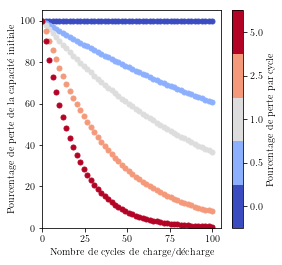

In [52]:
N = np.linspace(0,100)


def C(q : "percent loss", N : "cycle") : 
    if q == 1 :
        return 100 * np.ones(len(N))
    else : 
        return 100 * (1-q)**N

qs = np.array([0, 0.005, 0.01, 0.025, 0.05])


pen_matplotlib=colormap(len(qs), name = "coolwarm")

fig = plt.figure(figsize=(4,4))
ax = fig.subplots()
for n in range(len(qs)) : 
    ax.plot(N, C(qs[n],N), marker = 'o', ls = 'none', markersize = 5, color = pen_matplotlib[n], label = 'Points calculés')

ax.set_xlabel("Nombre de cycles de charge/décharge")
ax.set_ylabel("Pourcentage de perte de la capacité initiale")

ax.set_ylim(0,None)
ax.set_xlim(0,None)


# Create a colorbar with discrete color labels
bounds = np.arange(len(qs)+1) - 0.5
cmap= mcolors.ListedColormap(pen_matplotlib)
sm = plt.cm.ScalarMappable(cmap=cmap)
sm.set_array([])  # This step is necessary to create a mappable
cbar = plt.colorbar(sm, ticks=np.arange(len(qs)), boundaries = bounds)
cbar.set_ticklabels(qs*100)
cbar.set_label('Pourcentage de perte par cycle')
#cbar = plt.colorbar(cmap=cmap, ticks=bounds)
#cbar.set_ticklabels(colors)
#cbar.set_label('Colorbar Label')

fig.savefig("Fig07.pgf", dpi = _dpi)